In [43]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field, ValidationError
from typing import Literal, Optional


In [44]:
class UserState(BaseModel):
    name: str = Field(description="Name of the user")
    age: int = Field(default=0, ge=0, description="Age of the user in years (must be non-negative)")
    category: Optional[Literal["Junior", "Adult", "Senior"]] = None


In [45]:
def classify_age(state: UserState) -> dict:
    print(f"--- classify_age node called for {state.name} (age: {state.age}) ---")
    if state.age < 18:
        category = "Junior"
    elif state.age < 60:
        category = "Adult"
    else:
        category = "Senior"
    return {"category": category}

def welcome_node(state: UserState) -> dict:
    print(f"--- welcome node called for category: {state.category} ---")
    return {"name": f"Welcome {state.name} ({state.category})!"}


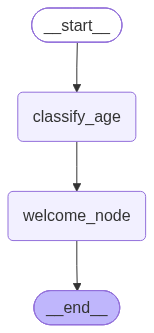

In [46]:
from IPython.display import Image, display

builder = StateGraph(UserState)

builder.add_node("classify_age", classify_age)
builder.add_node("welcome_node", welcome_node)

builder.add_edge(START, "classify_age")
builder.add_edge("classify_age", "welcome_node")
builder.add_edge("welcome_node", END)

graph = builder.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())


In [47]:
valid_result = graph.invoke({"name": "Krish", "age": 30})
print("Result with valid data:\n", valid_result)


--- classify_age node called for Krish (age: 30) ---
--- welcome node called for category: Adult ---
Result with valid data:
 {'name': 'Welcome Krish (Adult)!', 'age': 30, 'category': 'Adult'}


In [48]:
coerced_result = graph.invoke({"name": "Shivansh", "age": "25"})
print("Result with string age coerced to int:\n", coerced_result)


--- classify_age node called for Shivansh (age: 25) ---
--- welcome node called for category: Adult ---
Result with string age coerced to int:
 {'name': 'Welcome Shivansh (Adult)!', 'age': '25', 'category': 'Adult'}


In [49]:
try:
    graph.invoke({"name": "Krish", "age": "invalid_number"})
except ValidationError as e:
    print("Caught expected Pydantic ValidationError:")
    print(e)


Caught expected Pydantic ValidationError:
1 validation error for UserState
age
  Input should be a valid integer, unable to parse string as an integer [type=int_parsing, input_value='invalid_number', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/int_parsing


In [50]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY", "")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY", "")


In [52]:
from langchain_core.messages import AIMessage, HumanMessage

messages = [
    AIMessage(content="Please tell me how can I help you today.", name="Assistant"),
    HumanMessage(content="I want to learn coding", name="Krish"),
    AIMessage(content="Which programming language do you want to learn?", name="Assistant"),
    HumanMessage(content="I want to learn Python programming language.", name="Krish")
]

for message in messages:
    message.pretty_print()


================================== Ai Message ==================================
Name: Assistant

Please tell me how can I help you today.
================================ Human Message =================================
Name: Krish

I want to learn coding
================================== Ai Message ==================================
Name: Assistant

Which programming language do you want to learn?
================================ Human Message =================================
Name: Krish

I want to learn Python programming language.


In [58]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3.6-27b",api_key = os.getenv("GROQ_API_KEY"))
# Or with OpenAI:
# from langchain_openai import ChatOpenAI
# llm = ChatOpenAI(model="gpt-4o-mini")

result = llm.invoke(messages)
print("LLM Response:")
print(result.content)


LLM Response:

<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - User wants to learn Python programming language.
   - Previous context: User said "I want to learn coding", I asked which language, user specified Python.

2.  **Identify Key Needs:**
   - Beginner-friendly guidance for learning Python
   - Structured learning path
   - Resources (free/paid, interactive, books, videos)
   - Practical steps to start immediately
   - Encouragement and support

3.  **Determine Response Structure:**
   - Acknowledge choice (Python is great!)
   - Provide a clear, step-by-step learning roadmap
   - Recommend beginner resources
   - Suggest practical first steps
   - Offer ongoing support/guidance
   - Keep it concise and actionable

4.  **Draft - Section by Section:**
   *(Acknowledgment)* Great choice! Python is one of the most beginner-friendly and powerful programming languages out there. It's widely used in web development, data science, AI, automation, and more.

   *(R

In [59]:
print("Response Metadata:")
print(result.response_metadata)


Response Metadata:
{'token_usage': {'completion_tokens': 1512, 'prompt_tokens': 62, 'total_tokens': 1574, 'completion_time': 3.074576719, 'completion_tokens_details': None, 'prompt_time': 0.004711599, 'prompt_tokens_details': None, 'queue_time': 0.046146201, 'total_time': 3.079288318}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint': 'fp_2f860a3fc2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}


In [60]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """Add two integers a and b.

    Args:
        a (int): First integer.
        b (int): Second integer.

    Returns:
        int: The sum of a and b.
    """
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two integers a and b.

    Args:
        a (int): First integer.
        b (int): Second integer.

    Returns:
        int: The product of a and b.
    """
    return a * b

tools = [add, multiply]


In [61]:
### Binding tools with the LLM
llm_with_tools = llm.bind_tools(tools)

tool_call_response = llm_with_tools.invoke([HumanMessage(content="What is 2 plus 2?", name="Krish")])
print("AI Response content:", tool_call_response.content)
print("Tool Calls generated:", tool_call_response.tool_calls)


AI Response content: 
Tool Calls generated: [{'name': 'add', 'args': {'a': 2, 'b': 2}, 'id': '6mdvy9qfh', 'type': 'tool_call'}]


In [72]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


# class State(TypedDict):
#     messages :list[AnyMessage]

In [68]:
initial_messages = [
    AIMessage(content="Please tell me how can I help", name="Assistant"),
    HumanMessage(content="I want to learn coding", name="Krish")
]
ai_reply = AIMessage(content="Which programming language would you like to start with?", name="Assistant")

updated_messages = add_messages(initial_messages, ai_reply)
for msg in updated_messages:
    msg.pretty_print()


================================== Ai Message ==================================
Name: Assistant

Please tell me how can I help
================================ Human Message =================================
Name: Krish

I want to learn coding
================================== Ai Message ==================================
Name: Assistant

Which programming language would you like to start with?


In [69]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END

# State WITHOUT Reducer
class StateWithoutReducer(TypedDict):
    messages: list[AnyMessage]

# Node returns ONLY the new response
def bot_node(state: StateWithoutReducer) -> dict:
    new_reply = AIMessage(content="Which programming language would you like to start with?")
    return {"messages": [new_reply]}

# Build Graph
builder = StateGraph(StateWithoutReducer)
builder.add_node("bot", bot_node)
builder.add_edge(START, "bot")
builder.add_edge("bot", END)
graph = builder.compile()

# Initial input has 2 messages
initial_input = {
    "messages": [
        AIMessage(content="Please tell me how can I help"),
        HumanMessage(content="I want to learn coding")
    ]
}

result = graph.invoke(initial_input)
print("Total messages in state:", len(result["messages"]))
for msg in result["messages"]:
    print("-", msg.content)


Total messages in state: 1
- Which programming language would you like to start with?


In [70]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# State WITH Reducer
class StateWithReducer(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# Node returns ONLY the new response (exact same node code!)
def bot_node(state: StateWithReducer) -> dict:
    new_reply = AIMessage(content="Which programming language would you like to start with?")
    return {"messages": [new_reply]}

# Build Graph
builder = StateGraph(StateWithReducer)
builder.add_node("bot", bot_node)
builder.add_edge(START, "bot")
builder.add_edge("bot", END)
graph = builder.compile()

# Initial input has 2 messages
initial_input = {
    "messages": [
        AIMessage(content="Please tell me how can I help"),
        HumanMessage(content="I want to learn coding")
    ]
}

result = graph.invoke(initial_input)
print("Total messages in state:", len(result["messages"]))
for msg in result["messages"]:
    print("-", msg.content)


Total messages in state: 3
- Please tell me how can I help
- I want to learn coding
- Which programming language would you like to start with?


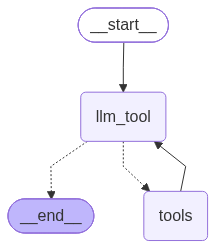

In [77]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

## Node definition
def llm_tool(state: State) -> dict:
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Build Graph
builder = StateGraph(State)

builder.add_node("llm_tool", llm_tool)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # If LLM generated tool_calls -> route to "tools"
    # If LLM generated normal text -> route to END
    tools_condition
)
# Loop back to llm_tool to synthesize the tool response
builder.add_edge("tools", "llm_tool")

graph = builder.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())


In [79]:
result = graph.invoke({"messages": [HumanMessage(content="What is 2 plus 2?")]})

print("\n--- Full Message History ---")
for message in result["messages"]:
    message.pretty_print()



--- Full Message History ---
================================ Human Message =================================

What is 2 plus 2?
================================== Ai Message ==================================
Tool Calls:
  add (gnkbv71sf)
 Call ID: gnkbv71sf
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4
================================== Ai Message ==================================

2 plus 2 is 4.


In [80]:
result_general = graph.invoke({"messages": [HumanMessage(content="What is Machine Learning?")]})

print("\n--- Full Message History ---")
for message in result_general["messages"]:
    message.pretty_print()



--- Full Message History ---
================================ Human Message =================================

What is Machine Learning?
================================== Ai Message ==================================

**Machine Learning (ML)** is a branch of artificial intelligence (AI) that focuses on building systems that can learn from data, identify patterns, and make decisions or predictions with minimal human intervention. Instead of being explicitly programmed with step-by-step rules, ML algorithms improve their performance over time as they are exposed to more information.

### 🔍 How It Works
1. **Data Collection:** Gather large amounts of relevant data.
2. **Training:** Feed the data into an algorithm, which analyzes it to find patterns or relationships.
3. **Model Building:** The algorithm creates a mathematical model that represents those patterns.
4. **Prediction/Decision:** The trained model is used to make predictions or decisions on new, unseen data.
5. **Iteration:** 